<a href="https://colab.research.google.com/github/eduramosalves/genai-biomedical-nlp/blob/main/biomedical_genai_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Biomedical Literature Intelligence — GenAI + NLP over PubMed

**Author:** Eduardo Ramos Alves · [GitHub](https://github.com/eduramosalves) · [LinkedIn](https://www.linkedin.com/in/eduardo-alves-418757227)

A small, end-to-end pipeline that collects real biomedical literature and applies modern NLP + Generative AI to it. The domain is arbovirus surveillance (Dengue, Zika, Chikungunya) — the same area I researched as a CNPq scholar.

**What this notebook does:**
1. **Collects data** — fetches PubMed abstracts via the NCBI Entrez API.
2. **NLP — zero-shot classification** — labels each abstract by theme with a Hugging Face transformer, *no training data required*.
3. **NLP — biomedical NER** — extracts diseases, genes and chemicals.
4. **Generative AI** — summarizes each abstract and synthesizes a mini literature review (Hugging Face locally, with an optional OpenAI path).
5. **Validation** — hand-labels a held-out sample and measures classifier accuracy.
6. **Visualization** — topic distribution, top entities, and entity types.

**Skills demonstrated:** Python · Hugging Face `transformers` · Generative AI / LLMs · NLP · model validation · data collection · Pandas · Scikit-Learn · Matplotlib · runs on Google Colab (free tier).

> Tip: open in Colab and set Runtime → Change runtime type → **GPU** for faster inference (CPU also works).

## 1. Setup
Install dependencies. On Colab this takes ~1 minute.

In [10]:
!pip install -q biopython transformers torch matplotlib pandas scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

pd.set_option('display.max_colwidth', 120)
print('Setup complete.')

Setup complete.


## 2. Data collection — PubMed via NCBI Entrez
NCBI requires an email for API access. We pull abstracts on arbovirus surveillance and keep the title + abstract text.

In [11]:
from Bio import Entrez

Entrez.email = 'eduardoramosalves23@gmail.com'  # required by NCBI

QUERY = '(dengue OR zika OR chikungunya) AND (genomic surveillance OR epidemiology OR diagnosis OR vaccine)'
N = 60

# 1) search for PubMed IDs
ids = Entrez.read(Entrez.esearch(db='pubmed', term=QUERY, retmax=N, sort='relevance'))['IdList']
print(f'Found {len(ids)} articles.')

# 2) fetch the records and parse title + abstract
records = Entrez.read(Entrez.efetch(db='pubmed', id=ids, rettype='xml'))

rows = []
for art in records['PubmedArticle']:
    cit = art['MedlineCitation']['Article']
    title = str(cit.get('ArticleTitle', ''))
    abs = cit.get('Abstract', {}).get('AbstractText', [])
    abstract = ' '.join(str(p) for p in abs).strip()
    if len(abstract) > 200:  # drop records with no usable abstract
        rows.append({'pmid': str(art['MedlineCitation']['PMID']), 'title': title, 'abstract': abstract})

df = pd.DataFrame(rows)
print(f'Kept {len(df)} abstracts with usable text.')
df.head(3)

Found 60 articles.
Kept 54 abstracts with usable text.


,pmid,title,abstract
0,40210848,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.","Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and Z..."
1,38196945,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.","Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 13..."
2,36801979,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.","Dengue, chikungunya and zika have caused significant epidemics in the Caribbean in recent years. This review highlig..."


## 3. NLP — zero-shot topic classification
Zero-shot lets us assign themes the model was never explicitly trained on. We define our own candidate labels and let the model score each abstract against them — no labeled training set needed.

In [12]:
classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli')

LABELS = ['epidemiology', 'diagnostics', 'vaccine', 'vector control',
          'genomics & sequencing', 'clinical treatment']

def top_topic(text):
    out = classifier(text[:1000], LABELS)  # truncate to keep inference fast
    return out['labels'][0], round(out['scores'][0], 3)

df[['topic', 'topic_score']] = df['abstract'].apply(lambda t: pd.Series(top_topic(t)))
df[['title', 'topic', 'topic_score']].head(8)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

,title,topic,topic_score
0,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.",epidemiology,0.616
1,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.",epidemiology,0.592
2,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.",epidemiology,0.738
3,"Zika, Chikungunya, and Other Emerging Vector-Borne Viral Diseases.",epidemiology,0.522
4,Mosquito-Borne Diseases.,diagnostics,0.671
5,[Not Available].,vector control,0.520
6,"Going Viral 2019: Zika, Chikungunya, and Dengue.",epidemiology,0.518
7,Immune Response to Dengue and Zika.,epidemiology,0.368


## 4. NLP — biomedical named-entity recognition (NER)
Extract structured entities (diseases, genes, chemicals) from free text using a domain-specific transformer.

In [13]:
import re
from collections import Counter

ner = pipeline('token-classification', model='d4data/biomedical-ner-all',
               aggregation_strategy='max')

# This model frequently emits sub-word fragments ("den", "##ika", "z") instead
# of whole entities, which makes raw corpus counts unreadable. We clean each
# span and canonicalize the handful of arbovirus names that get split, so the
# section-7 chart shows real entities instead of token noise.
DISEASE_STEMS = {
    'dengue':       ('den', 'deng', 'denv', 'dengv'),
    'zika':         ('z', 'ika', 'zikv', 'ika virus'),
    'chikungunya':  ('chi', 'chik', 'chikv'),
    'yellow fever': ('yellow',),
    'arbovirus':    ('arbo', 'arbovir'),
}

def clean_entity(word):
    """Normalize a raw NER span to a canonical entity, or None to drop it."""
    w = re.sub(r'[^a-z ]', '', word.replace('##', '').lower()).strip()
    if not w:
        return None
    for canon, frags in DISEASE_STEMS.items():
        if canon in w:        # full name present as substring -> canonical form
            return canon
        if w in frags:        # known noisy fragment (exact match) -> canonical
            return canon
    return w if len(w) >= 4 else None   # drop leftover 1-3 char fragments

# Show the cleaned entities for one abstract.
sample = df.iloc[0]['abstract']
print('Sample abstract:', df.iloc[0]['title'], '\n')
seen = set()
for e in ner(sample[:1000]):
    w = clean_entity(e['word'])
    if w and e['score'] > 0.6 and (w, e['entity_group']) not in seen:
        seen.add((w, e['entity_group']))
        print(f"  {e['entity_group']:<22} {w:<28} ({e['score']:.2f})")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Sample abstract: The overlapping global distribution of dengue, chikungunya, Zika and yellow fever. 

  Disease_disorder       arbovirus                    (1.00)
  Detailed_description   aedes                        (0.81)
  Coreference            stegomyia                    (0.85)
  Detailed_description   aegypti                      (0.99)
  Detailed_description   albopictus                   (0.99)
  Disease_disorder       aedes                        (0.98)
  Detailed_description   borne                        (0.96)
  Lab_value              billion                      (0.68)
  Detailed_description   yellow fever                 (0.89)
  Coreference            feve                         (0.94)


In [14]:
# Corpus-level counts for the section-7 charts:
#   entity_counter -> cleaned & merged named entities (what)
#   type_counter   -> entity groups: Disease, Chemical, Gene... (what kind)
# Counting types is robust even when the model splits a name into sub-words.
entity_counter = Counter()
type_counter = Counter()

for text in df['abstract']:
    for e in ner(text[:1000]):
        if e['score'] <= 0.6:
            continue
        type_counter[e['entity_group']] += 1
        w = clean_entity(e['word'])
        if w:
            entity_counter[w] += 1

print('Top 15 named entities (cleaned & merged):')
for word, count in entity_counter.most_common(15):
    print(f'  {word:<28} {count}')

print('\nEntity types across the corpus:')
for grp, count in type_counter.most_common():
    print(f'  {grp:<28} {count}')

Top 15 named entities (cleaned & merged):
  dengue                       58
  zika                         43
  chikungunya                  26
  arbovirus                    21
  infections                   20
  virus                        9
  severe                       9
  high                         8
  infection                    6
  viruses                      5
  uveitis                      5
  mosquito                     5
  infectious                   4
  clusters                     4
  maternal                     4

Entity types across the corpus:
  Disease_disorder             207
  Detailed_description         199
  Diagnostic_procedure         105
  Lab_value                    91
  Sign_symptom                 51
  Coreference                  21
  Severity                     20
  Biological_structure         11
  Subject                      11
  Nonbiological_location       10
  Quantitative_concept         5
  Age                          5
  Therapeutic_pr

## 5. Generative AI — summarization + synthesis
First a local Hugging Face generative model condenses each abstract. Then we generate a short synthesized overview across the corpus. An optional OpenAI cell shows the same idea with a hosted LLM.

In [15]:
# Some transformers builds (e.g. current Colab) don't register the 'summarization'
# pipeline task, so we load the seq2seq model directly and call generate() instead.
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = 'sshleifer/distilbart-cnn-12-6'
tok = AutoTokenizer.from_pretrained(model_id)
mdl = AutoModelForSeq2SeqLM.from_pretrained(model_id)

def summarize(text):
    inputs = tok(text[:1024], return_tensors='pt', truncation=True)
    ids = mdl.generate(**inputs, max_length=60, min_length=20, num_beams=4)
    return tok.decode(ids[0], skip_special_tokens=True)

df['summary'] = df['abstract'].apply(summarize)
df[['title', 'summary']].head(5)

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

,title,summary
0,"The overlapping global distribution of dengue, chikungunya, Zika and yellow fever.","Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and ..."
1,"Integrated control strategies for dengue, Zika, and Chikungunya virus infections.","Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 1..."
2,"Dengue, chikungunya and zika arbovirus infections in Caribbean children.","Dengue has been increasingly intense and severe, seroprevalence is 80-100% in the Caribbean . Children have increas..."
3,"Zika, Chikungunya, and Other Emerging Vector-Borne Viral Diseases.","Arthropod-borne viruses (arboviruses) have a long history of emerging to infect humans, but during recent decades, ..."
4,Mosquito-Borne Diseases.,Mosquito-borne diseases have become more common as previously geographically isolated diseases have spread globally...


In [16]:
# OPTIONAL — higher-quality synthesis with an OpenAI model.
# Skips itself cleanly if no API key is set, so the notebook always runs.
import os

def synthesize_with_openai(summaries):
    from openai import OpenAI
    client = OpenAI()  # reads OPENAI_API_KEY from the environment
    joined = '\n'.join(f'- {s}' for s in summaries[:20])
    prompt = ('You are a biomedical research assistant. Given these abstract '
              'summaries on arbovirus surveillance, write a 4-sentence synthesis '
              f'of the main themes and gaps:\n\n{joined}')
    resp = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}])
    return resp.choices[0].message.content

if os.getenv('OPENAI_API_KEY'):
    print(synthesize_with_openai(df['summary'].tolist()))
else:
    print('No OPENAI_API_KEY set — skipping hosted-LLM synthesis.')
    print('Local fallback synthesis (concatenated top summaries):\n')
    print(' '.join(df['summary'].head(5)))

No OPENAI_API_KEY set — skipping hosted-LLM synthesis.
Local fallback synthesis (concatenated top summaries):

 Arboviruses transmitted mainly by Aedes (Stegomyia) aegypti and Ae. albopictus, including dengue, chikungunya, and . Zika viruses, and yellow fever virus in urban settings, pose an escalating global  Arboviruses are a major threat to public health in tropical regions, encompassing over 534 distinct species, with 134 capable of causing diseases in humans . Dengue virus stands out as the most prevalent, annually affecting approximately 16.2 million individuals solely in the Americas .  Dengue has been increasingly intense and severe, seroprevalence is 80-100% in the Caribbean . Children have increased attributable morbidity and mortality . Chikungunya, a togavirus, affected 80% of some Caribbean populations .  Arthropod-borne viruses (arboviruses) have a long history of emerging to infect humans, but during recent decades, they have been spreading more widely and affecting larg

## 6. Validation
A model is only useful if we check it. I take a deterministic held-out sample, **read each abstract and hand-label it by PMID** (step 1 prints them, step 2 holds the labels), then measure how often the zero-shot classifier agrees. Labels are keyed by PMID rather than row position, so the score is correct even though PubMed's relevance ordering shifts between runs. This is the habit the IBM role asks for: *train, validate, and document under supervision.*

In [17]:
# Step 1 — take a deterministic held-out sample and READ it.
# Sorting by PMID makes the sample stable across runs, so the labels you
# write below always line up with the right abstract (PubMed's relevance
# order is not stable, which is why positional labels are unreliable).
holdout = df.sort_values('pmid').head(15).reset_index(drop=True)

for _, r in holdout.iterrows():
    print(f"\nPMID {r['pmid']} — {r['title']}")
    print(r['abstract'][:600], '...')
    print(f"  >> model predicted: {r['topic']} ({r['topic_score']})")

print('\nChoose true labels from:', LABELS)


PMID 26942903 — [Dengue, Zika and Chikungunya].
Arboviruses are transmitted by arthropods, including those responsible for the current pandemic: alphavirus (Chikungunya) and flaviviruses (dengue and Zika). Its importance increased in the Americas over the past 20 years. The main vectors are Aedes aegypti and A. albopictus. Dengue infection provides long lasting immunity against the specific serotype and temporary to the other three. Subsequent infection by another serotype determines more serious disease. There is a registered vaccine for dengue, Dengvaxia (Sanofi Pasteur). Other two (Butantan and Takeda) are in Phase III in 2016. Zika infe ...
  >> model predicted: vaccine (0.356)

PMID 27833670 — Dengue, Zika and Chikungunya: Emerging Arboviruses in the New World.
The arboviruses that cause dengue, chikungunya, and Zika illnesses have rapidly expanded across the globe in recent years, with large-scale outbreaks occurring in Western Hemisphere territories in close proximity to the Un

In [22]:
# Step 2 — fill in the TRUE label for each PMID after reading it above.
# Keyed by PMID, so the scoring stays correct regardless of result ordering.
# Leave a PMID out and it's simply excluded from the metric (no fake numbers).
from sklearn.metrics import accuracy_score, classification_report

GROUND_TRUTH = {
    '26942903': 'epidemiology',
    '27833670': 'epidemiology',
    '28432975': 'vaccine',
    '28846489': 'epidemiology',
    '29270717': 'clinical treatment',
    '29473899': 'vaccine',
    '29635625': 'clinical treatment',
    '29845536': 'vaccine',
    '30011271': 'epidemiology',
    '30115330': 'diagnostics',
    '30210503': 'epidemiology',
    '30466692': 'clinical treatment',
    '30474222': 'clinical treatment',
    '30869010': 'epidemiology',
}

labeled = holdout[holdout['pmid'].isin(GROUND_TRUTH)].copy()
if labeled.empty:
    print('No labels filled in yet.')
    print('Read the abstracts printed above, then add entries to GROUND_TRUTH')
    print('using one of these labels:', LABELS)
else:
    labeled['true_label'] = labeled['pmid'].map(GROUND_TRUTH)
    acc = accuracy_score(labeled['true_label'], labeled['topic'])
    print(f'Hand-labeled {len(labeled)}/{len(holdout)} abstracts.')
    print(f'Zero-shot accuracy on the labeled holdout: {acc:.0%}\n')
    print(classification_report(labeled['true_label'], labeled['topic'], zero_division=0))

Hand-labeled 14/15 abstracts.
Zero-shot accuracy on the labeled holdout: 64%

                    precision    recall  f1-score   support

clinical treatment       0.50      0.25      0.33         4
       diagnostics       0.50      1.00      0.67         1
      epidemiology       0.67      0.67      0.67         6
           vaccine       0.75      1.00      0.86         3

          accuracy                           0.64        14
         macro avg       0.60      0.73      0.63        14
      weighted avg       0.62      0.64      0.61        14



## 7. Visualization
Three views of the corpus: topic distribution, the most frequent biomedical entities (cleaned and merged), and the breakdown of entity *types* (disease, chemical, gene…) — the last is robust even when the NER model splits a name into sub-word tokens.

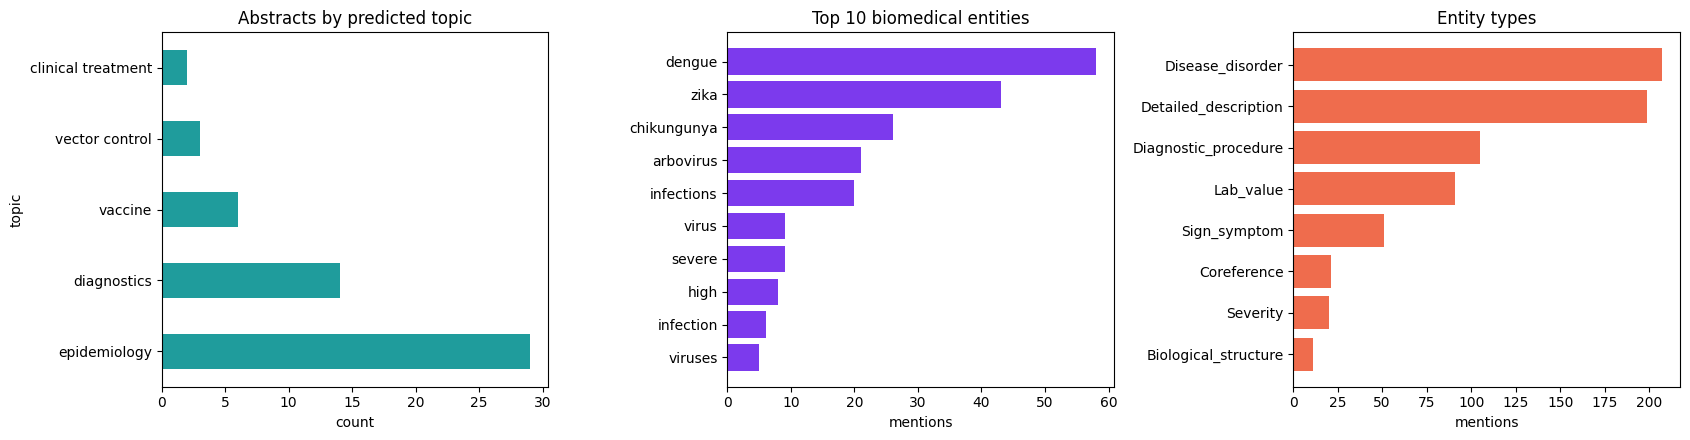

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

df['topic'].value_counts().plot(kind='barh', ax=axes[0], color='#1f9c9c')
axes[0].set_title('Abstracts by predicted topic')
axes[0].set_xlabel('count')

top = dict(entity_counter.most_common(10))
axes[1].barh(list(top.keys())[::-1], list(top.values())[::-1], color='#7c3aed')
axes[1].set_title('Top 10 biomedical entities')
axes[1].set_xlabel('mentions')

types = dict(type_counter.most_common(8))
axes[2].barh(list(types.keys())[::-1], list(types.values())[::-1], color='#ef6c4d')
axes[2].set_title('Entity types')
axes[2].set_xlabel('mentions')

plt.tight_layout()
plt.show()

## 8. Conclusion & next steps

This pipeline goes from raw PubMed text to classified, entity-tagged, and summarized output — combining classical NLP (zero-shot classification, NER) with Generative AI (abstractive summarization, LLM synthesis), validated against a hand-labeled sample.

**What I'd do next:**
- Replace the local summarizer with a RAG setup: embed abstracts (sentence-transformers) and answer free-text questions over the corpus.
- Fine-tune or few-shot the classifier on a larger hand-labeled set and report per-class F1.
- Add an AI-agent layer that, given a research question, plans the PubMed query, runs the pipeline, and returns a cited brief.
- Deploy as a small Streamlit app and containerize for a cloud runtime.

*Built by Eduardo Ramos Alves — biomedical scientist transitioning into data science & GenAI.*